In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Indian_Kids_Screen_Time.csv")

print("Dataset loaded ")
print("Shape:", df.shape)
print(df.head())

Dataset loaded 
Shape: (9712, 8)
   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                      5.89     Smartphone   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

           Health_Impacts Urban_or_Rural  
0  Poor Sleep, Eye Strain          Urban  
1              Poor Sleep          Urban  
2              Poor Sleep          Urban  
3                     NaN      

In [13]:
df['Health_Impacts'] = df['Health_Impacts'].fillna('No Health Impact')

In [14]:
df.isnull().sum()

,0
Age,0
Gender,0
Avg_Daily_Screen_Time_hr,0
Primary_Device,0
Exceeded_Recommended_Limit,0
Educational_to_Recreational_Ratio,0
Health_Impacts,0
Urban_or_Rural,0
Device_Mobility,0
Usage_Pattern,0


In [15]:
df.describe()

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio,Health_Issue_Count
count,9712.000000,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226,1.037068
std,3.162437,1.718232,0.073221,0.914570
min,8.000000,0.000000,0.300000,0.000000
25%,10.000000,3.410000,0.370000,0.000000
50%,13.000000,4.440000,0.430000,1.000000
75%,16.000000,5.380000,0.480000,2.000000
max,18.000000,13.890000,0.600000,4.000000


In [16]:
## Device Mobility

df["Device_Mobility"] = df["Primary_Device"].map({
    "TV": "Wall-Mounted",
    "Desktop": "Fixed Device",
    "Laptop": "Portable",
    "Tablet": "Portable",
    "Smartphone": "Portable"
}).fillna("Unknown")

In [17]:
## Usage Pattern

def classify_usage(ratio):
    if pd.isna(ratio):
        return "Unknown"
    elif ratio >= 1.2:
        return "Education Dominant"
    elif ratio <= 0.8:
        return "Recreation Dominant"
    else:
        return "Balanced Usage"

df["Usage_Pattern"] = df["Educational_to_Recreational_Ratio"].apply(classify_usage)


In [18]:
## Screen Time Level (Mean-based)
mean_screen_time = df["Avg_Daily_Screen_Time_hr"].mean()

df["Screen_Time_Level"] = np.where(
    df["Avg_Daily_Screen_Time_hr"] > mean_screen_time,
    "Above Average",
    "Below Average"
)

In [19]:
## WEEKEND/ WEEKDAYS
mean_screen_time = df["Avg_Daily_Screen_Time_hr"].mean()

df["Screen_Time_Type"] = np.where(
    df["Avg_Daily_Screen_Time_hr"] > mean_screen_time,
    "Heavy Usage",
    "Light Usage"
)

In [20]:
mean_usage = df["Avg_Daily_Screen_Time_hr"].mean()

df["Usage_Pattern"] = np.where(
    df["Avg_Daily_Screen_Time_hr"] > mean_usage,
    "Leisure-like",
    "Workday-like"
)

In [21]:
##health risk
df["Health_Impacts_Clean"] = (
    df["Health_Impacts"]
    .fillna("")
    .str.lower()
    .str.strip()
)

df.loc[df["Health_Impacts_Clean"] == "none", "Health_Impacts_Clean"] = ""

df["Health_Issue_Count"] = df["Health_Impacts_Clean"].apply(
    lambda x: 0 if x == "" else len([i.strip() for i in x.split(",")])
)

def health_risk_level(count):
    if count == 0:
        return "No Issues"
    elif count == 1:
        return "Mild Risk"
    elif count == 2:
        return "Moderate Risk"
    else:
        return "High Risk"

df["Health_Risk_Level"] = df["Health_Issue_Count"].apply(health_risk_level)



In [22]:
## final
df.to_csv("Indian_Kids_Screen_Time_Derived.csv", index=False)

print("All derived features created successfully!")
print(df.head(10))


All derived features created successfully!
   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                      5.89     Smartphone   
5   14  Female                      4.88     Smartphone   
6   17    Male                      2.97             TV   
7   10    Male                      2.74             TV   
8   14    Male                      4.61         Laptop   
9   18    Male                      3.24         Tablet   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False      

In [23]:
# Derive Health Risk directly (NO extra columns)

df["Health_Risk_Level"] = np.select(
    [
        df["Health_Impacts"].str.contains("Anxiety|Obesity Risk", case=False, na=False),
        df["Health_Impacts"].str.contains("Poor Sleep|Eye Strain", case=False, na=False),
        df["Health_Impacts"].str.contains("None", case=False, na=False)
    ],
    [
        "High Risk",
        "Medium Risk",
        "Low Risk"
    ],
    default="Medium Risk"
)

In [12]:
df

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Device_Mobility,Usage_Pattern,Screen_Time_Level,Screen_Time_Type,Health_Impacts_Clean,Health_Issue_Count,Health_Risk_Level
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Portable,Workday-like,Below Average,Light Usage,"poor sleep, eye strain",2,Medium Risk
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Portable,Leisure-like,Above Average,Heavy Usage,poor sleep,1,Medium Risk
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Wall-Mounted,Workday-like,Below Average,Light Usage,poor sleep,1,Medium Risk
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban,Portable,Workday-like,Below Average,Light Usage,,0,Medium Risk
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Portable,Leisure-like,Above Average,Heavy Usage,"poor sleep, anxiety",2,High Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban,Portable,Workday-like,Below Average,Light Usage,poor sleep,1,Medium Risk
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural,Portable,Leisure-like,Above Average,Heavy Usage,poor sleep,1,Medium Risk
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural,Portable,Leisure-like,Above Average,Heavy Usage,"poor sleep, eye strain, anxiety",3,High Risk
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban,Wall-Mounted,Leisure-like,Above Average,Heavy Usage,poor sleep,1,Medium Risk


SINGLE NUMERICAL


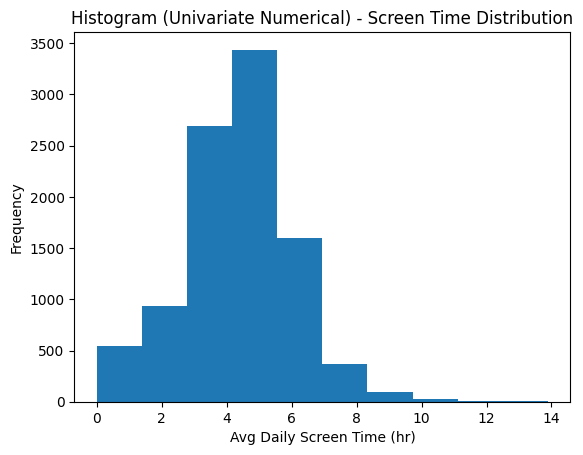

In [ ]:
#  histogram
plt.figure()
plt.hist(df["Avg_Daily_Screen_Time_hr"], bins=10)
plt.title("Histogram (Univariate Numerical) - Screen Time Distribution")
plt.xlabel("Avg Daily Screen Time (hr)")
plt.ylabel("Frequency")
plt.show()

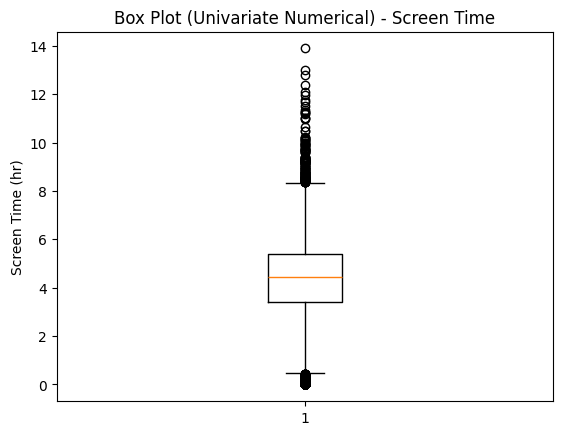

In [ ]:
# Box Plot
plt.figure()
plt.boxplot(df["Avg_Daily_Screen_Time_hr"])
plt.title("Box Plot (Univariate Numerical) - Screen Time")
plt.ylabel("Screen Time (hr)")
plt.show()

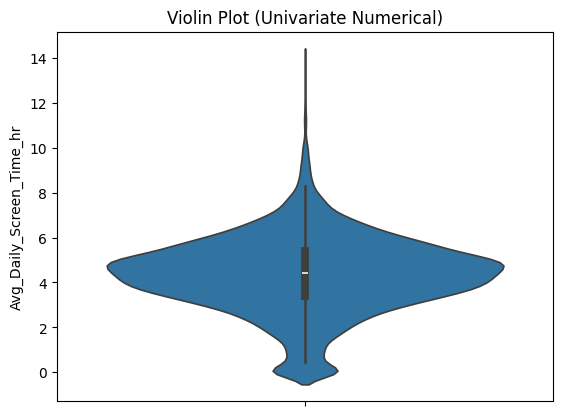

In [ ]:
# Violin Plot
plt.figure()
sns.violinplot(y=df["Avg_Daily_Screen_Time_hr"])
plt.title("Violin Plot (Univariate Numerical)")
plt.show()

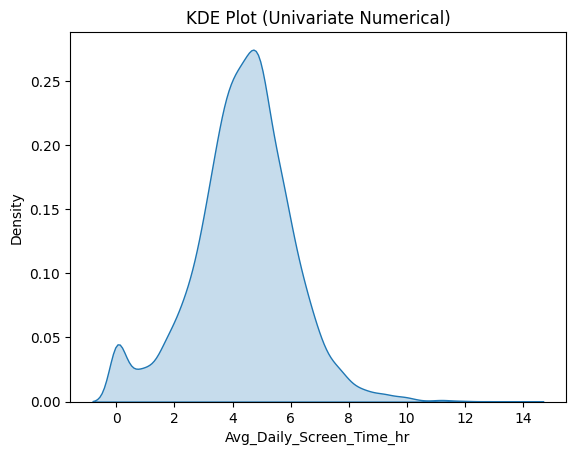

In [ ]:
#  KDE Plot (Density Plot)
plt.figure()
sns.kdeplot(df["Avg_Daily_Screen_Time_hr"], fill=True)
plt.title("KDE Plot (Univariate Numerical)")
plt.show()

SINGLE CATEGORICAL COLUMN (Univariate – Categorical)

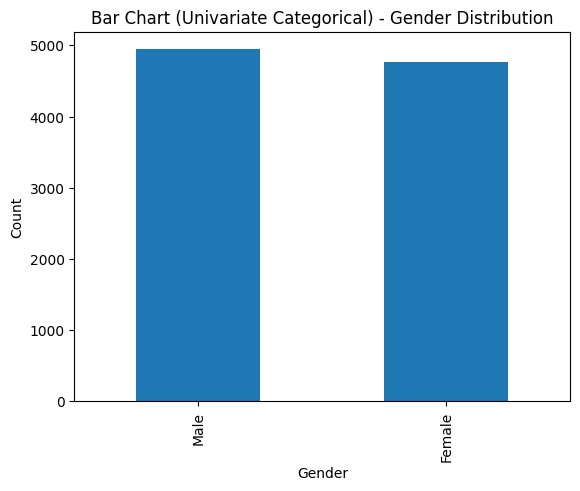

In [ ]:
plt.figure()
df["Gender"].value_counts().plot(kind="bar")
plt.title("Bar Chart (Univariate Categorical) - Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

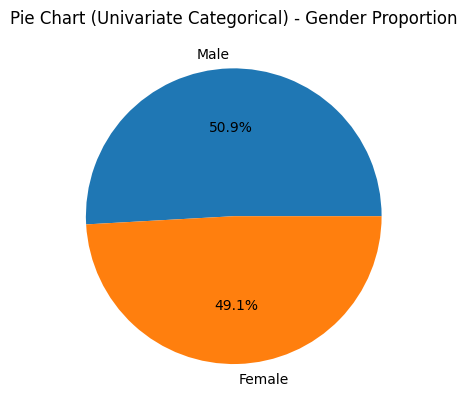

In [ ]:
# Pie Chart
plt.figure()
df["Gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Pie Chart (Univariate Categorical) - Gender Proportion")
plt.ylabel("")
plt.show()

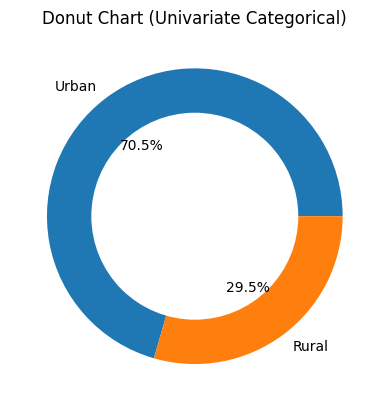

In [ ]:
# Donut Chart
plt.figure()
counts = df["Urban_or_Rural"].value_counts()

plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Donut Chart (Univariate Categorical)")
plt.show()

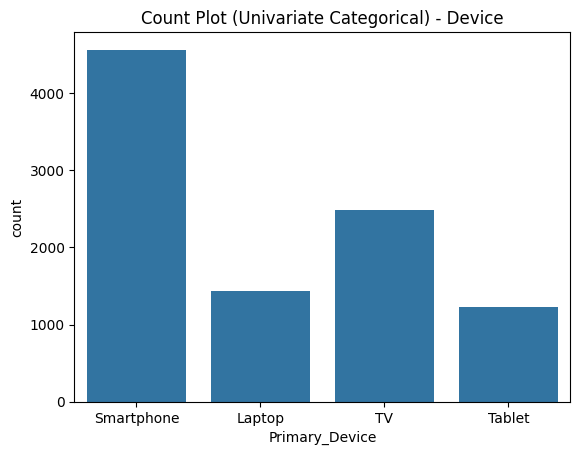

In [ ]:
# Count Plot (Seaborn)
plt.figure()
sns.countplot(data=df, x="Primary_Device")
plt.title("Count Plot (Univariate Categorical) - Device")
plt.show()

NUMERICAL vs NUMERICAL (Bivariate – Numerical vs Numerical)

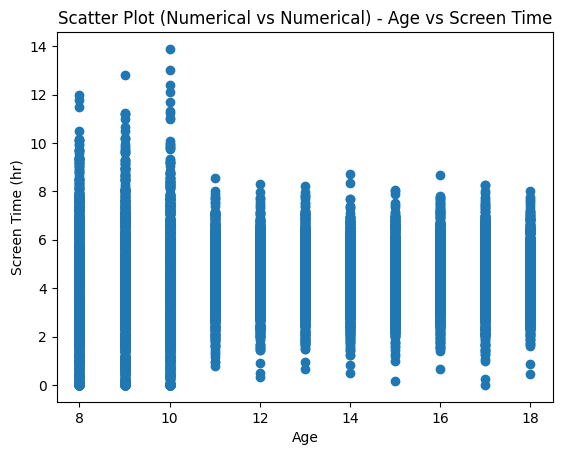

In [ ]:
# Scatter Plot
plt.figure()
plt.scatter(df["Age"], df["Avg_Daily_Screen_Time_hr"])
plt.title("Scatter Plot (Numerical vs Numerical) - Age vs Screen Time")
plt.xlabel("Age")
plt.ylabel("Screen Time (hr)")
plt.show()

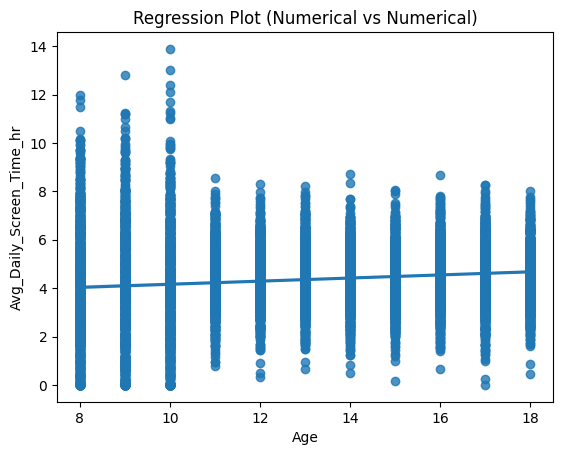

In [ ]:
# Regression Plot
plt.figure()
sns.regplot(x="Age", y="Avg_Daily_Screen_Time_hr", data=df)
plt.title("Regression Plot (Numerical vs Numerical)")
plt.show()

In [ ]:
# Line Plot
plt.figure()
sns.lineplot(x="Age", y="Avg_Daily_Screen_Time_hr", data=df)
plt.title("Line Plot - Age vs Screen Time")
plt.show()